In [316]:
import numpy as np
from matplotlib import pyplot as plt
from decimal import Decimal, getcontext, ROUND_HALF_UP
import math

getcontext().rounding = ROUND_HALF_UP

In [317]:
def mu(x, k, mean):
    sum = np.sum((x-mean)**k)
    return sum/np.size(x)

def mode(x):
    unique, counts = np.unique(x, return_counts=True)
    max_count = np.max(counts)
    modes = unique[counts == max_count]
    return modes

def asymmetry(x):
    mean = np.mean(x)
    mu_3 = mu(x, 3, mean)
    mu_2 = mu(x, 2, mean)
    return mu_3/mu_2**(3/2)

In [318]:
n = 25
x = np.random.exponential(scale=1, size=n)
print(x)

[1.00925105 0.641535   0.32835655 0.47651899 0.6955836  0.40393094
 0.6589258  2.54807327 0.33129375 0.22982746 2.38458204 0.53529599
 0.9151198  0.1202165  0.15206115 0.42492298 0.94761382 0.86078777
 0.27354947 1.57723093 1.45293135 1.03425808 0.79109934 0.0466016
 3.87541144]


In [319]:
median = np.median(x)
scope = x.max() - x.min()
mean = np.mean(x)
asymmetry_x = asymmetry(x)
modes = mode(x)

In [320]:
print(f"медиана = {median}\n размах = {scope}\n коэффициент ассиметрии = {asymmetry_x}\n моды :{modes if np.size(modes)<n else 'всего по 1'}")

медиана = 0.6589258027622737
 размах = 3.8288098400842143
 коэффициент ассиметрии = 1.8991591681188476
 моды :всего по 1


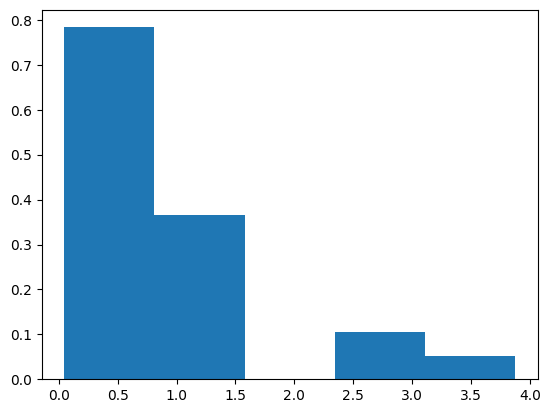

In [321]:
plt.hist(x, bins=int(Decimal(1+np.log2(n))), density=True)
plt.show()

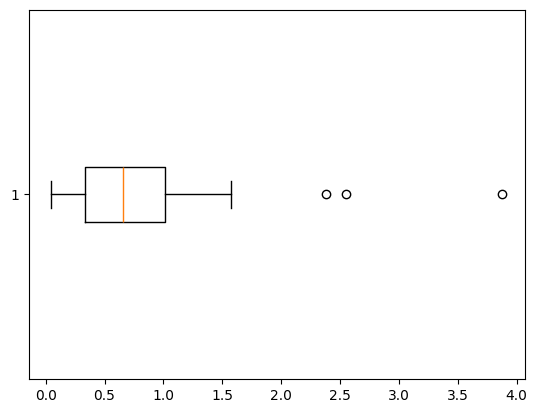

In [322]:
plt.boxplot(x, vert=False)
plt.show()

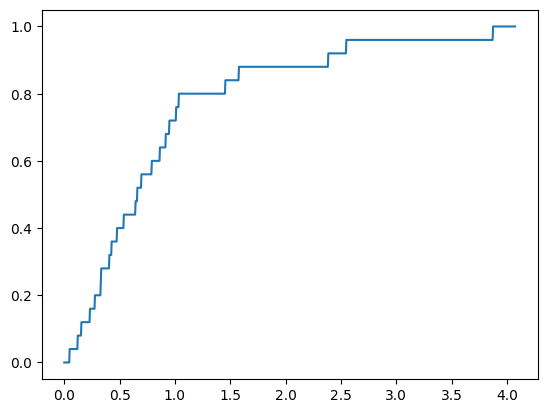

In [323]:
def empirical_cdf(data, x):
    return np.sum(data <= x)/np.size(data)

ax_x = np.linspace(0, x.max()+0.2, 1000)
ax_y = [empirical_cdf(x, i) for i in ax_x]

plt.plot(ax_x, ax_y)
plt.show()

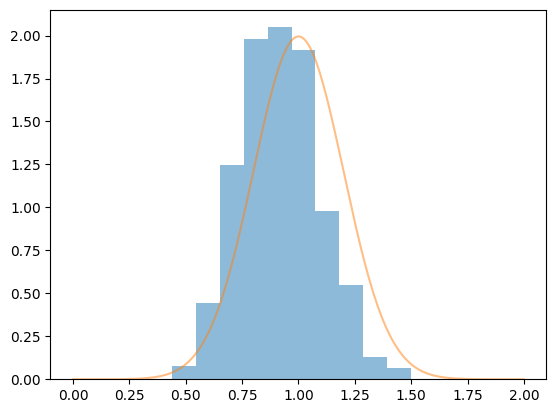

In [324]:
def subsample(x, n):
    mask = np.random.randint(0, n, size=n)
    sub_x = x[mask]
    return sub_x

def gaussian_pdf(x, mu=1, sigma=1/5):
    return (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-(x - mu)**2 / (2 * sigma**2))

def bootstrap_mean(x, n, N):
    statistic = np.zeros(N)
    for i in range (0, N):
        sub_x = subsample(x, n)
        statistic[i] = np.mean(sub_x)

    bins=int(Decimal(1+np.log2(N)))
    plt.hist(statistic, bins=bins, density=True,  alpha=0.5)

    mu = 1
    sigma = 1/5
    ax_x = np.linspace(0, 2, N)
    ax_y = gaussian_pdf(ax_x, mu, sigma)
    plt.plot(ax_x, ax_y, alpha=0.5)
    plt.show()

N = 1000
bootstrap_mean(x, np.size(x), N)

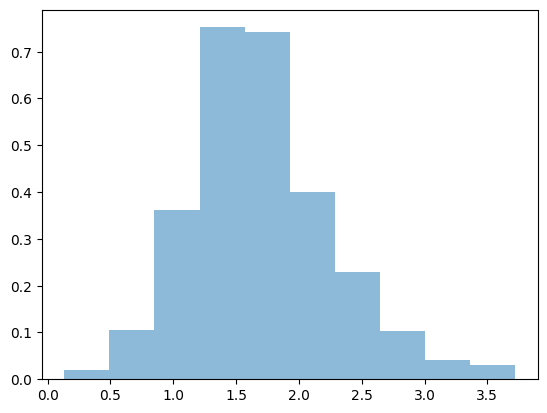

P(asymmetry < 1) = 0.086


In [325]:
def bootstrap_asymmetry(x, n, N):
    statistic = np.zeros(N)
    for i in range (0, N):
        sub_x = subsample(x, n)
        statistic[i] = asymmetry(sub_x)

    bins=int(Decimal(1+np.log2(N)))
    plt.hist(statistic, bins=bins, density=True,  alpha=0.5)
    plt.show()
    return statistic


statistic = bootstrap_asymmetry(x, np.size(x), N)
probability = np.mean(statistic < 1)
print(f"P(asymmetry < 1) = {probability}")

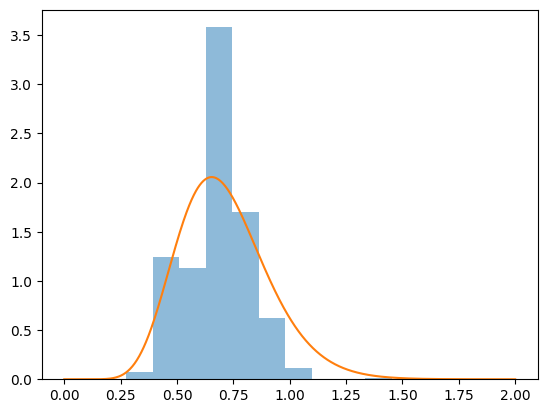

In [326]:
def bootstrap_median(x, n, N):
    statistic = np.zeros(N)
    for i in range (0, N):
        sub_x = subsample(x, n)
        statistic[i] = np.median(sub_x)

    bins=int(Decimal(1+np.log2(N)))
    plt.hist(statistic, bins=bins, density=True,  alpha=0.5)

    ax_x = np.linspace(0, 2, N)
    ax_y = np.zeros(N)
    for i in range((n+1)//2, n+1):
        ax_y += math.comb(n, i) * np.exp(-ax_x*(n-i)) * (1 - np.exp(-ax_x))**(i-1) * (n*np.exp(-ax_x) - n + i)
    
    plt.plot(ax_x, ax_y)
    plt.show()

bootstrap_median(x, np.size(x), N)
